In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min'
# Np_str='1e6'

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [3]:
############################
#LOADING DATA

In [4]:
#NEEDED TO PLOT THE CORRECT DATA
data_type="Tracked_Area"

In [5]:
# #OLD
# #LOADING BACK IN
# dir2=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# input_file=dir2+f"CL_nonCL_tracked_Area_profiles_{res}_{t_res}_{Np_str}.h5"

# with open(input_file, "rb") as f:
#     profile_dict = pickle.load(f)

# # Dynamically create variables from the dictionary
# for var_name, value in profile_dict.items():
#     globals()[var_name] = value  # Assign to global namespace

In [6]:
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

In [7]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

In [8]:
############################
#PLOTTING

In [9]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

In [10]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

Minimum Cloudbase is: 1.2463867664337158



(-1.579972701719098, 50.24765185798401)
(-0.8313374039717019, 18.140085513237864)


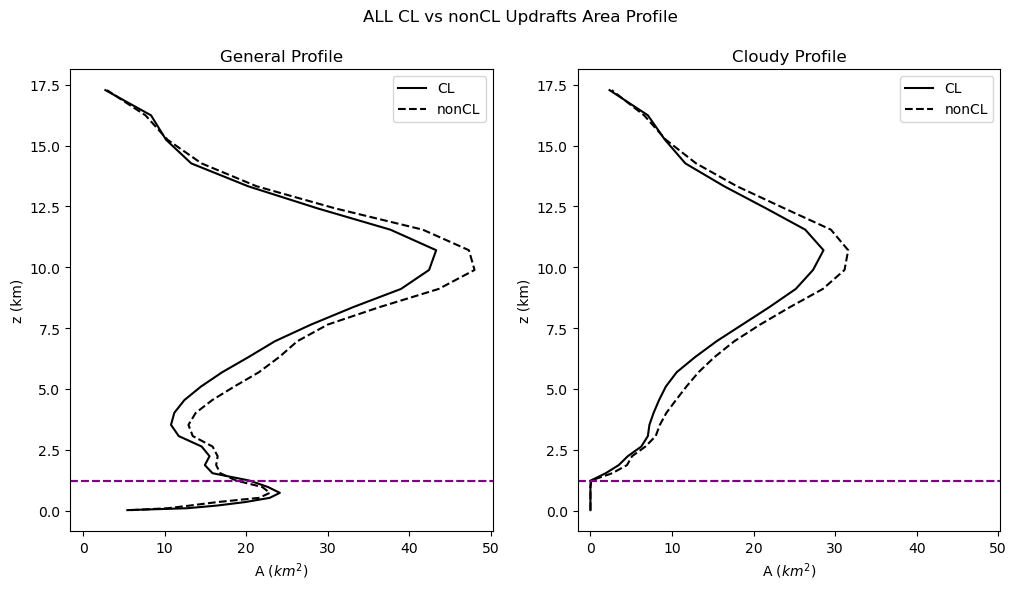

In [11]:

fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(CL_ALL_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='CL')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(CL_ALL_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='CL')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonCL_ALL_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='nonCL',linestyle='dashed')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonCL_ALL_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='nonCL',linestyle='dashed')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('ALL CL vs nonCL Updrafts Area Profile')
ax[0].legend();ax[1].legend()

(-0.5750236553445606, 24.511622280471652)
(-0.168677353579551, 4.2242244550026955)


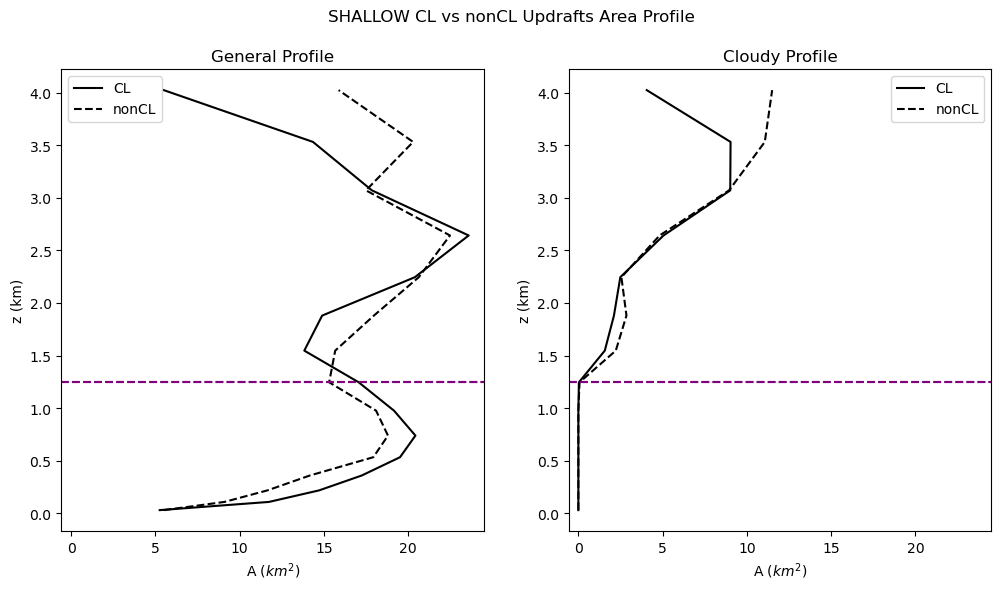

In [12]:

fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(CL_SHALLOW_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='CL')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(CL_SHALLOW_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='CL')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonCL_SHALLOW_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='nonCL',linestyle='dashed')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonCL_SHALLOW_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='nonCL',linestyle='dashed')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('SHALLOW CL vs nonCL Updrafts Area Profile')
ax[0].legend();ax[1].legend()

(-1.5817747092221106, 68.54886975948207)
(-0.8313374039717019, 18.140085513237864)


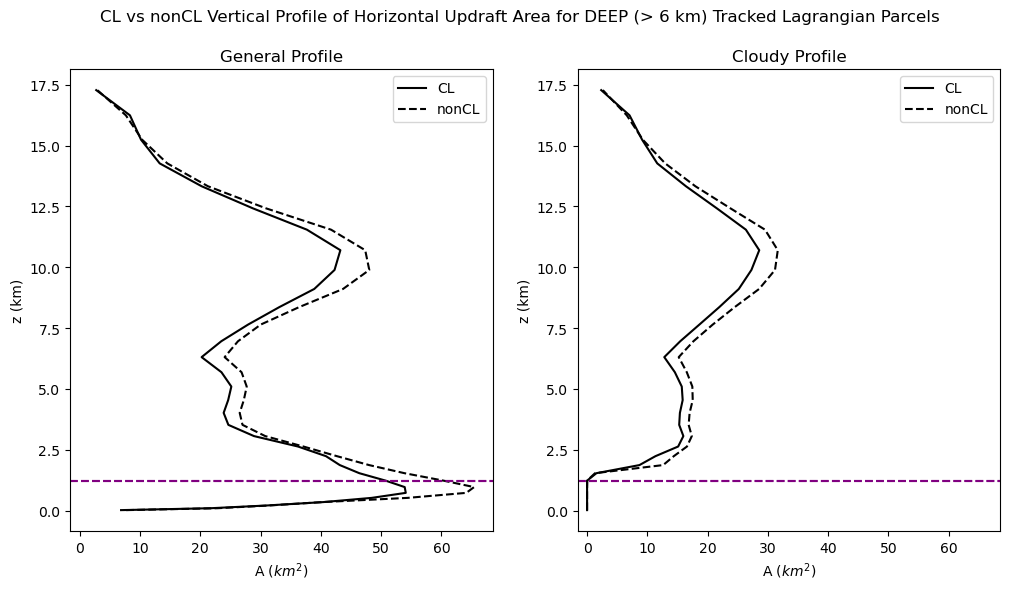

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(CL_DEEP_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='black',label='CL')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(CL_DEEP_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='black',label='CL')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonCL_DEEP_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],linestyle='dashed',color='black',label='nonCL')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonCL_DEEP_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],linestyle='dashed',color='black',label='nonCL')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('CL vs nonCL Vertical Profile of Horizontal Updraft Area for DEEP (> 6 km) Tracked Lagrangian Parcels')
ax[0].legend();ax[1].legend()

In [14]:
#######################
#SBZ vs nonSBZ

In [15]:
############################
#PLOTTING

In [16]:
# #OLD
# #LOADING BACK IN
# dir2=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# input_file=dir2+f"SBZ_nonSBZ_tracked_Area_profiles_{res}_{t_res}_{Np_str}.h5"

# with open(input_file, "rb") as f:
#     profile_dict = pickle.load(f)

# # Dynamically create variables from the dictionary
# for var_name, value in profile_dict.items():
#     globals()[var_name] = value  # Assign to global namespace

In [17]:
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

(-1.4723073065730592, 72.13723899935466)
(-0.8313374039717019, 18.140085513237864)


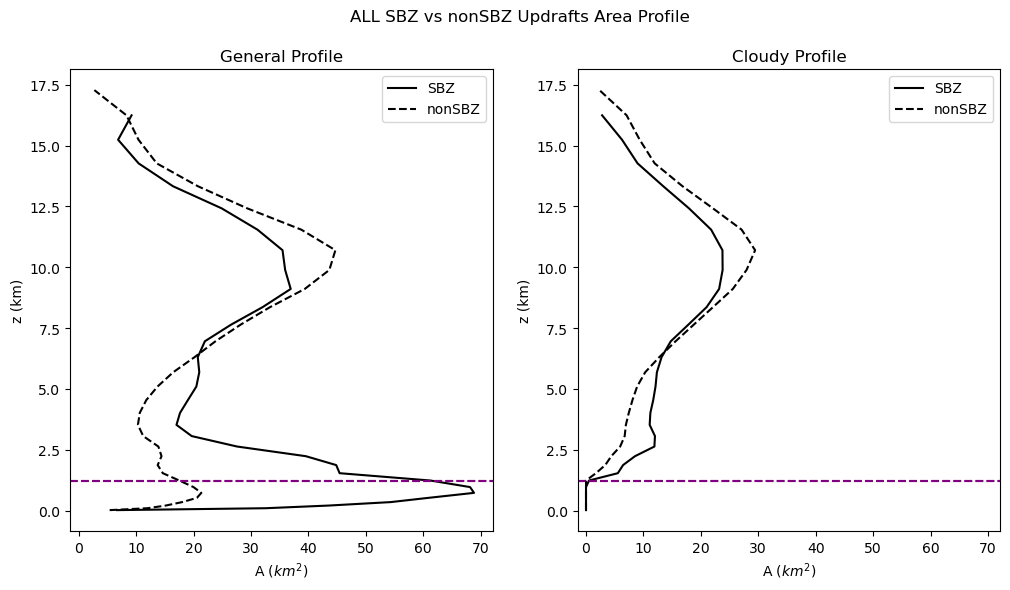

In [18]:

fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(SBZ_ALL_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='SBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(SBZ_ALL_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='SBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonSBZ_ALL_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='nonSBZ',linestyle='dashed')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonSBZ_ALL_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='nonSBZ',linestyle='dashed')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('ALL SBZ vs nonSBZ Updrafts Area Profile')
ax[0].legend();ax[1].legend()

(-1.031579863579614, 100.86490011808341)
(-0.168677353579551, 4.2242244550026955)


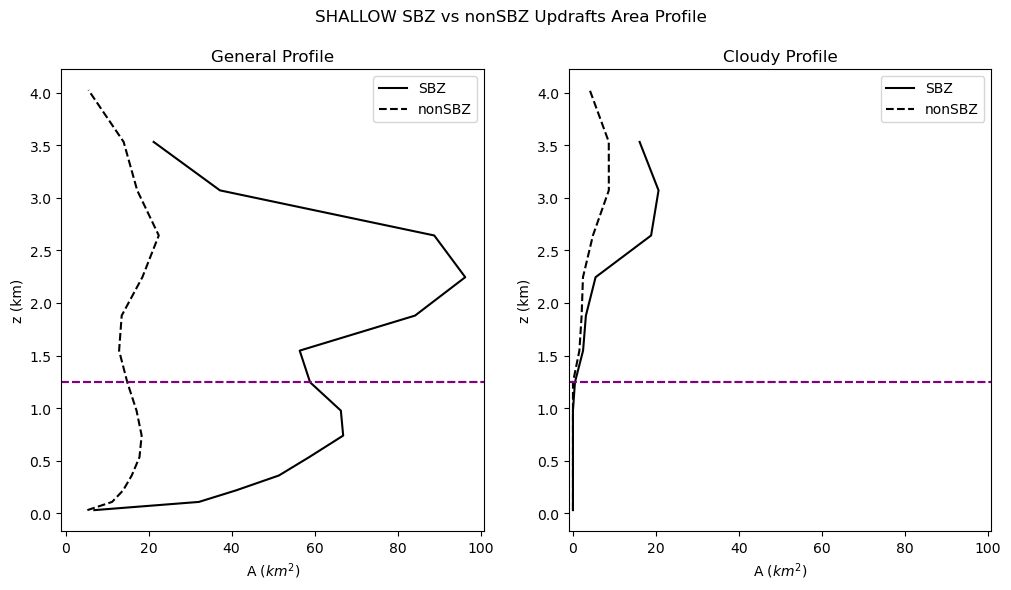

In [19]:

fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(SBZ_SHALLOW_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='SBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(SBZ_SHALLOW_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='SBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonSBZ_SHALLOW_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='nonSBZ',linestyle='dashed')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonSBZ_SHALLOW_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='nonSBZ',linestyle='dashed')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('SHALLOW SBZ vs nonSBZ Updrafts Area Profile')
ax[0].legend();ax[1].legend()

(-1.4718015046918023, 74.1225073999407)
(-0.8313374039717019, 18.140085513237864)


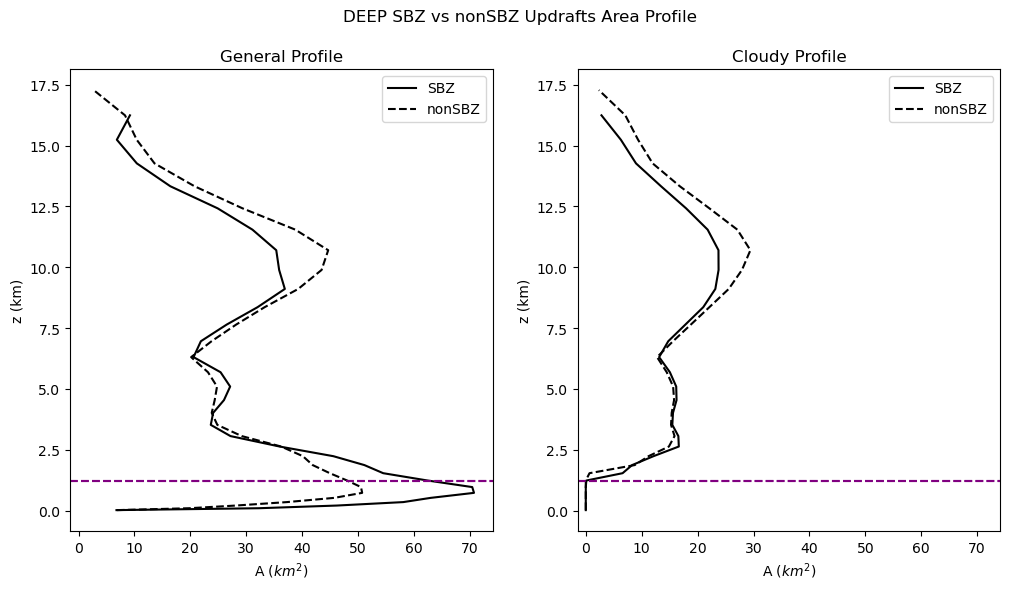

In [20]:

fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(SBZ_DEEP_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='SBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(SBZ_DEEP_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='SBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(nonSBZ_DEEP_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='nonSBZ',linestyle='dashed')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(nonSBZ_DEEP_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='nonSBZ',linestyle='dashed')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('DEEP SBZ vs nonSBZ Updrafts Area Profile')
ax[0].legend();ax[1].legend()

In [ ]:
#######################
#COLD POOL

In [ ]:
#############################
#PLOTTING

In [ ]:
# #OLD
# #LOADING BACK IN
# dir2=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# input_file=dir2+f"ColdPool_tracked_Area_profiles_{res}_{t_res}_{Np_str}.h5"

# with open(input_file, "rb") as f:
#     profile_dict = pickle.load(f)

# # Dynamically create variables from the dictionary
# for var_name, value in profile_dict.items():
#     globals()[var_name] = value  # Assign to global namespace

In [ ]:
type1='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(SBZ_ALL_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='SBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(SBZ_ALL_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='SBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(ColdPool_ALL_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='ColdPool',linestyle='dashed')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(ColdPool_ALL_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='ColdPool',linestyle='dashed')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('ALL SBZ vs ColdPool Updrafts Area Profile')
ax[0].legend();ax[1].legend()

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(SBZ_SHALLOW_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='SBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(SBZ_SHALLOW_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='SBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(ColdPool_SHALLOW_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='ColdPool',linestyle='dashed')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(ColdPool_SHALLOW_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='ColdPool',linestyle='dashed')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('SHALLOW SBZ vs ColdPool Updrafts Area Profile')
ax[0].legend();ax[1].legend()

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
ax = ax.flatten()

# Plot for general profile
out_general = averaged_profiles(SBZ_DEEP_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='SBZ')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(SBZ_DEEP_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='SBZ')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')

# Plot for general profile
out_general = averaged_profiles(ColdPool_DEEP_profile_array_general)
ax[0].plot(out_general[:, 0], out_general[:, 1],color='k',label='ColdPool',linestyle='dashed')
ax[0].set_xlabel(f'A ({r"$km^2$"})')
ax[0].set_ylabel('z (km)')
ax[0].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[0].set_title('General Profile')

# Plot for cloudy profile
out_cloudy = averaged_profiles(ColdPool_DEEP_profile_array_cloudy)
ax[1].plot(out_cloudy[:, 0], out_cloudy[:, 1],color='k',label='ColdPool',linestyle='dashed')
ax[1].set_xlabel(f'A ({r"$km^2$"})')
ax[1].set_ylabel('z (km)')
ax[1].axhline(all_cloudbase, color='purple', linestyle='dashed')
ax[1].set_title('Cloudy Profile')


fix_x_limits([ax[0],ax[1]])
fix_y_limits([ax[0],ax[1]])

plt.suptitle('DEEP CL vs ColdPool Updrafts Area Profile')
ax[0].legend();ax[1].legend()